In [2]:
import pandas as pd
import sqlite3
from datetime import datetime

# Connect to SQLite database (or create it if it doesn't exist)
conn = sqlite3.connect('../data/analytics.db')



In [ ]:
# Extract RFM Base data
query="""
SELECT 
    customer_id,
    MAX(ts) AS last_purchase_date,
    COUNT(DISTINCT transaction_id) AS frequency,
    SUM(total_amount) AS monetary_value
FROM transactions
GROUP BY customer_id
"""
rfm=pd.read_sql_query(query, conn)
rfm

,customer_id,last_purchase_date,frequency,monetary_value
0,1,2025-09-03T02:05:31.699573,5,251.71
1,2,2025-08-31T22:46:31.699573,14,835.83
2,3,2025-09-24T07:35:31.699573,15,804.70
3,4,2025-09-24T04:32:31.699573,13,939.31
4,5,2025-09-04T18:09:31.699573,8,608.64
...,...,...,...,...
1995,1996,2025-03-18T17:22:31.699573,7,419.20
1996,1997,2025-08-18T10:13:31.699573,13,733.69
1997,1998,2025-09-15T01:09:31.699573,5,395.00
1998,1999,2025-09-06T19:03:31.699573,9,681.73


In [12]:
# Compute Recency (days since last purchase)

# Convert to datetime
rfm['last_purchase_date'] = pd.to_datetime(rfm['last_purchase_date'])

# Find the latest purchase date in the dataset for Reference
latest_date= rfm['last_purchase_date'].max()
print(latest_date)

# Calculate Recency
rfm['recency days']= (latest_date - rfm['last_purchase_date']).dt.days
rfm.head()

2025-09-25 10:48:31.699573


,customer_id,last_purchase_date,frequency,monetary_value,recency days
0,1,2025-09-03 02:05:31.699573,5,251.71,22
1,2,2025-08-31 22:46:31.699573,14,835.83,24
2,3,2025-09-24 07:35:31.699573,15,804.70,1
3,4,2025-09-24 04:32:31.699573,13,939.31,1
4,5,2025-09-04 18:09:31.699573,8,608.64,20


In [ ]:
# Score Each RFM Component (1-5 scale)

# Higher frequency and monetary value are better
# Lower recency (more recent) is better
rfm['R_score']= pd.qcut(rfm['recency days'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score']= pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score']= pd.qcut(rfm['monetary_value'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)

# Combine into RFM Score
rfm['RFM_score']= rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm.head()

,customer_id,last_purchase_date,frequency,monetary_value,recency days,R_score,F_score,M_score,RFM_score
0,1,2025-09-03 02:05:31.699573,5,251.71,22,3,1,1,311
1,2,2025-08-31 22:46:31.699573,14,835.83,24,3,5,5,355
2,3,2025-09-24 07:35:31.699573,15,804.70,1,5,5,5,555
3,4,2025-09-24 04:32:31.699573,13,939.31,1,5,5,5,555
4,5,2025-09-04 18:09:31.699573,8,608.64,20,3,2,4,324


In [ ]:
# Segment Customers

def segment_customer(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4:
        return 'Champions'
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] >= 4 and row['F_score'] <= 2:
        return 'Recent Customers'
    elif row['R_score'] <= 2 and row['F_score'] >= 4:
        return 'Frequent Customers'
    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'At Risk'
    else:
        return 'Others'
    
rfm['segment']= rfm.apply(segment_customer, axis=1)
print(rfm.head())
rfm['segment'].value_counts()

   customer_id         last_purchase_date  frequency  monetary_value  \
0            1 2025-09-03 02:05:31.699573          5          251.71   
1            2 2025-08-31 22:46:31.699573         14          835.83   
2            3 2025-09-24 07:35:31.699573         15          804.70   
3            4 2025-09-24 04:32:31.699573         13          939.31   
4            5 2025-09-04 18:09:31.699573          8          608.64   

   recency days  R_score  F_score  M_score RFM_score          segment  
0            22        3        1        1       311           Others  
1            24        3        5        5       355  Loyal Customers  
2             1        5        5        5       555        Champions  
3             1        5        5        5       555        Champions  
4            20        3        2        4       324           Others  


segment
Loyal Customers       423
At Risk               394
Others                386
Champions             377
Recent Customers      272
Frequent Customers    148
Name: count, dtype: int64

In [25]:
# Time Based Sales Analysis

# Sales by Day of Week
query="""
SELECT 
    strftime('%w', ts) AS day_of_week,
    SUM(total_amount) AS total_sales
FROM transactions
GROUP BY day_of_week
ORDER BY day_of_week
"""
sales_by_day=pd.read_sql_query(query, conn)
# print(sales_by_day)
sales_by_day['day_of_week']= sales_by_day['day_of_week'].astype(int)
print(sales_by_day)
sales_by_day['day_of_week']= sales_by_day['day_of_week'].map({
    0: 'Sunday',
    1: 'Monday',
    2: 'Tuesday',             
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday',
})
print(sales_by_day)

# Sales by Hour of Day
query="""
SELECT 
    strftime('%H', ts) AS hour_of_day,
    SUM(total_amount) AS total_sales
FROM transactions
GROUP BY hour_of_day
ORDER BY hour_of_day
"""
sales_by_hour=pd.read_sql_query(query, conn)
sales_by_hour['hour_of_day']= sales_by_hour['hour_of_day'].astype(int)
print(sales_by_hour)

   day_of_week  total_sales
0            0    157513.61
1            1    156245.89
2            2    159401.18
3            3    162002.88
4            4    159890.69
5            5    153021.37
6            6    157380.03
  day_of_week  total_sales
0      Sunday    157513.61
1      Monday    156245.89
2     Tuesday    159401.18
3   Wednesday    162002.88
4    Thursday    159890.69
5      Friday    153021.37
6    Saturday    157380.03
    hour_of_day  total_sales
0             0     43590.80
1             1     45320.23
2             2     46752.01
3             3     49571.18
4             4     50025.02
5             5     43562.06
6             6     48346.27
7             7     46972.88
8             8     44119.60
9             9     44331.11
10           10     45786.87
11           11     49018.06
12           12     48014.58
13           13     44134.92
14           14     42121.42
15           15     46047.18
16           16     43721.28
17           17     45872.75
18       

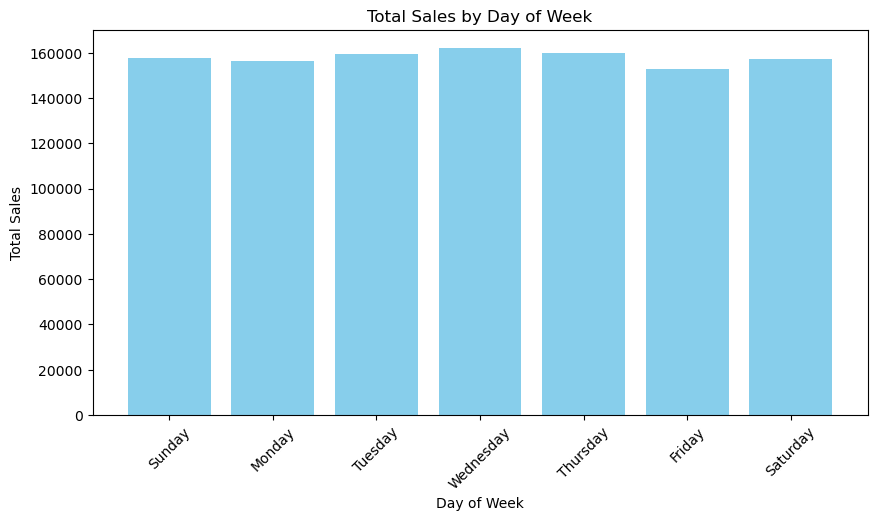

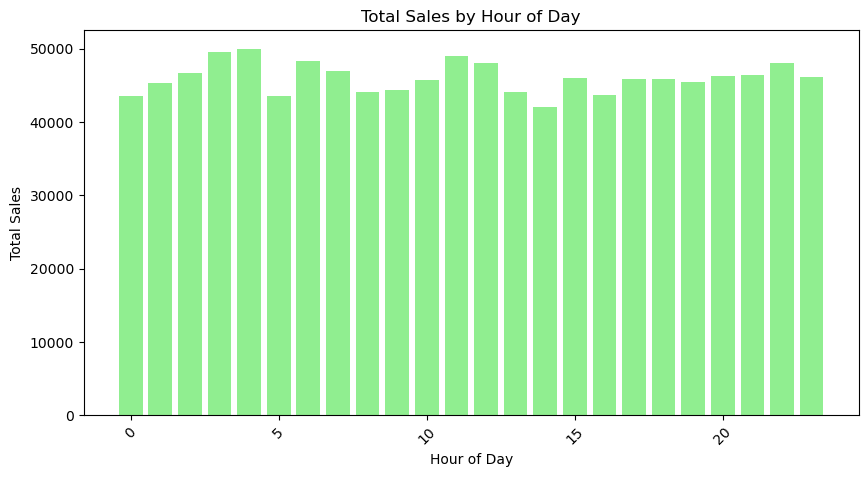

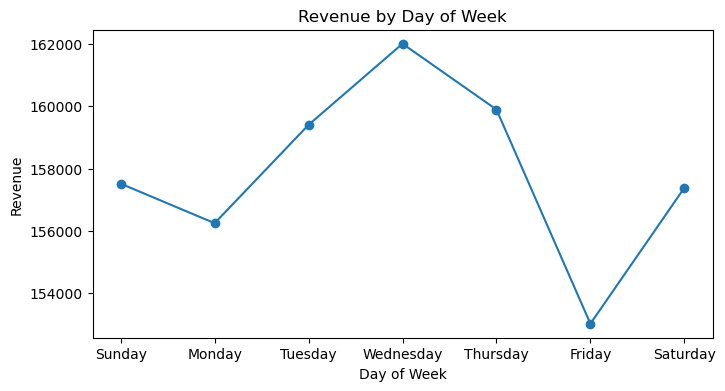

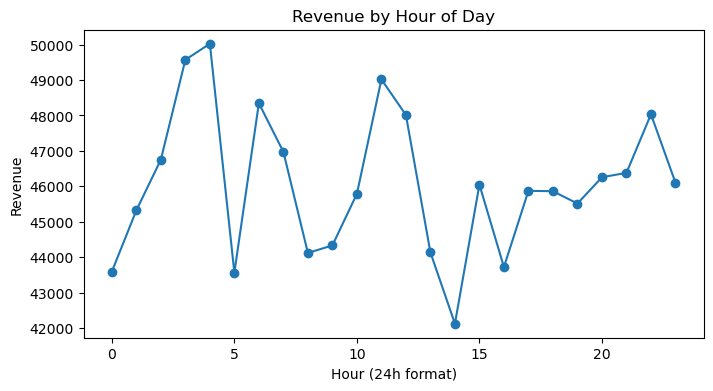

In [29]:
# Visualize
import matplotlib.pyplot as plt

# Sales by Day of Week
plt.figure(figsize=(10,5))
plt.bar(sales_by_day['day_of_week'], sales_by_day['total_sales'], color='skyblue')
plt.title('Total Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

# Sales by Hour of Day
plt.figure(figsize=(10,5))
plt.bar(sales_by_hour['hour_of_day'], sales_by_hour['total_sales'], color='lightgreen')
plt.title('Total Sales by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

# Line Plot for Sales by Day of Week
plt.figure(figsize=(8,4))
plt.plot(sales_by_day["day_of_week"], sales_by_day["total_sales"], marker="o")
plt.title("Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Revenue")
plt.show()

# Line Plot for Sales by Hour of Day
plt.figure(figsize=(8,4))
plt.plot(sales_by_hour["hour_of_day"], sales_by_hour["total_sales"], marker="o")
plt.title("Revenue by Hour of Day")
plt.xlabel("Hour (24h format)")
plt.ylabel("Revenue")
plt.show()